In [ ]:
!pip install kagglehub

In [ ]:
import kagglehub

path = kagglehub.dataset_download("uciml/mushroom-classification")
print("Dataset downloaded to:", path)

100%|██████████| 34.2k/34.2k [00:00<00:00, 37.7MB/s]

Extracting files...
Dataset downloaded to: /root/.cache/kagglehub/datasets/uciml/mushroom-classification/versions/1


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [ ]:
import os

dataset_dir = '/root/.cache/kagglehub/datasets/uciml/mushroom-classification/versions/1'
csv_file = os.path.join(dataset_dir, 'mushrooms.csv')

df = pd.read_csv(csv_file)
print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
df.head()

Dataset loaded successfully!
Shape: (8124, 23)


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [ ]:
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [ ]:
print("Dataset Information:")
print("="*50)
df.info()
print("\n" + "="*50)
print(f"Total Samples: {len(df)}")
print(f"Total Features: {df.shape[1]}")

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  sta

In [ ]:
print("Missing Values Check:")
print("="*50)
missing = df.isnull().sum()
print(missing)
print("\n" + "="*50)
print(f"Total Missing Values: {missing.sum()}")

Missing Values Check:
class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64

Total Missing Values: 0


In [ ]:
print("Target Class Distribution:")
print("="*50)
print(df['class'].value_counts())
print("\n" + "="*50)
print(df['class'].value_counts(normalize=True) * 100)

Target Class Distribution:
class
e    4208
p    3916
Name: count, dtype: int64

class
e    51.797144
p    48.202856
Name: proportion, dtype: float64


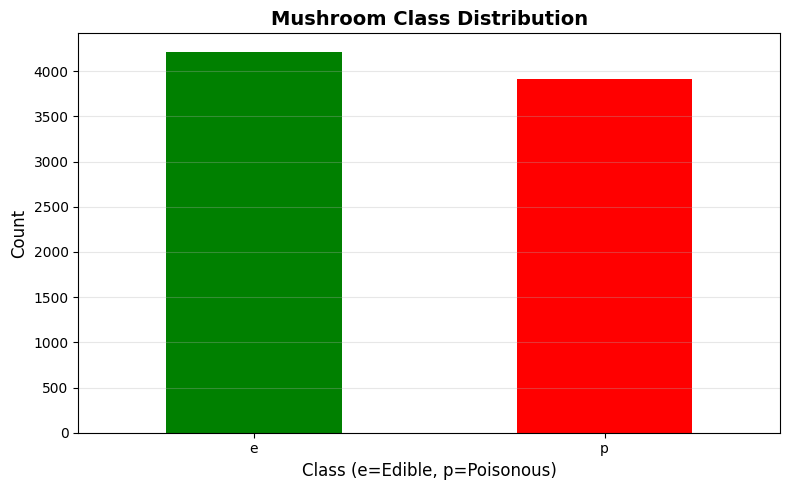

In [ ]:
plt.figure(figsize=(8, 5))
df['class'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Mushroom Class Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Class (e=Edible, p=Poisonous)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
print("Unique Values in Each Feature:")
print("="*50)
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

Unique Values in Each Feature:
class: 2 unique values
cap-shape: 6 unique values
cap-surface: 4 unique values
cap-color: 10 unique values
bruises: 2 unique values
odor: 9 unique values
gill-attachment: 2 unique values
gill-spacing: 2 unique values
gill-size: 2 unique values
gill-color: 12 unique values
stalk-shape: 2 unique values
stalk-root: 5 unique values
stalk-surface-above-ring: 4 unique values
stalk-surface-below-ring: 4 unique values
stalk-color-above-ring: 9 unique values
stalk-color-below-ring: 9 unique values
veil-type: 1 unique values
veil-color: 4 unique values
ring-number: 3 unique values
ring-type: 5 unique values
spore-print-color: 9 unique values
population: 6 unique values
habitat: 7 unique values


In [ ]:
print("Unique Value Categories:")
print("="*50)
for col in df.columns:
    print(f"\n{col}: {sorted(df[col].unique())}")

Unique Value Categories:

class: ['e', 'p']

cap-shape: ['b', 'c', 'f', 'k', 's', 'x']

cap-surface: ['f', 'g', 's', 'y']

cap-color: ['b', 'c', 'e', 'g', 'n', 'p', 'r', 'u', 'w', 'y']

bruises: ['f', 't']

odor: ['a', 'c', 'f', 'l', 'm', 'n', 'p', 's', 'y']

gill-attachment: ['a', 'f']

gill-spacing: ['c', 'w']

gill-size: ['b', 'n']

gill-color: ['b', 'e', 'g', 'h', 'k', 'n', 'o', 'p', 'r', 'u', 'w', 'y']

stalk-shape: ['e', 't']

stalk-root: ['?', 'b', 'c', 'e', 'r']

stalk-surface-above-ring: ['f', 'k', 's', 'y']

stalk-surface-below-ring: ['f', 'k', 's', 'y']

stalk-color-above-ring: ['b', 'c', 'e', 'g', 'n', 'o', 'p', 'w', 'y']

stalk-color-below-ring: ['b', 'c', 'e', 'g', 'n', 'o', 'p', 'w', 'y']

veil-type: ['p']

veil-color: ['n', 'o', 'w', 'y']

ring-number: ['n', 'o', 't']

ring-type: ['e', 'f', 'l', 'n', 'p']

spore-print-color: ['b', 'h', 'k', 'n', 'o', 'r', 'u', 'w', 'y']

population: ['a', 'c', 'n', 's', 'v', 'y']

habitat: ['d', 'g', 'l', 'm', 'p', 'u', 'w']


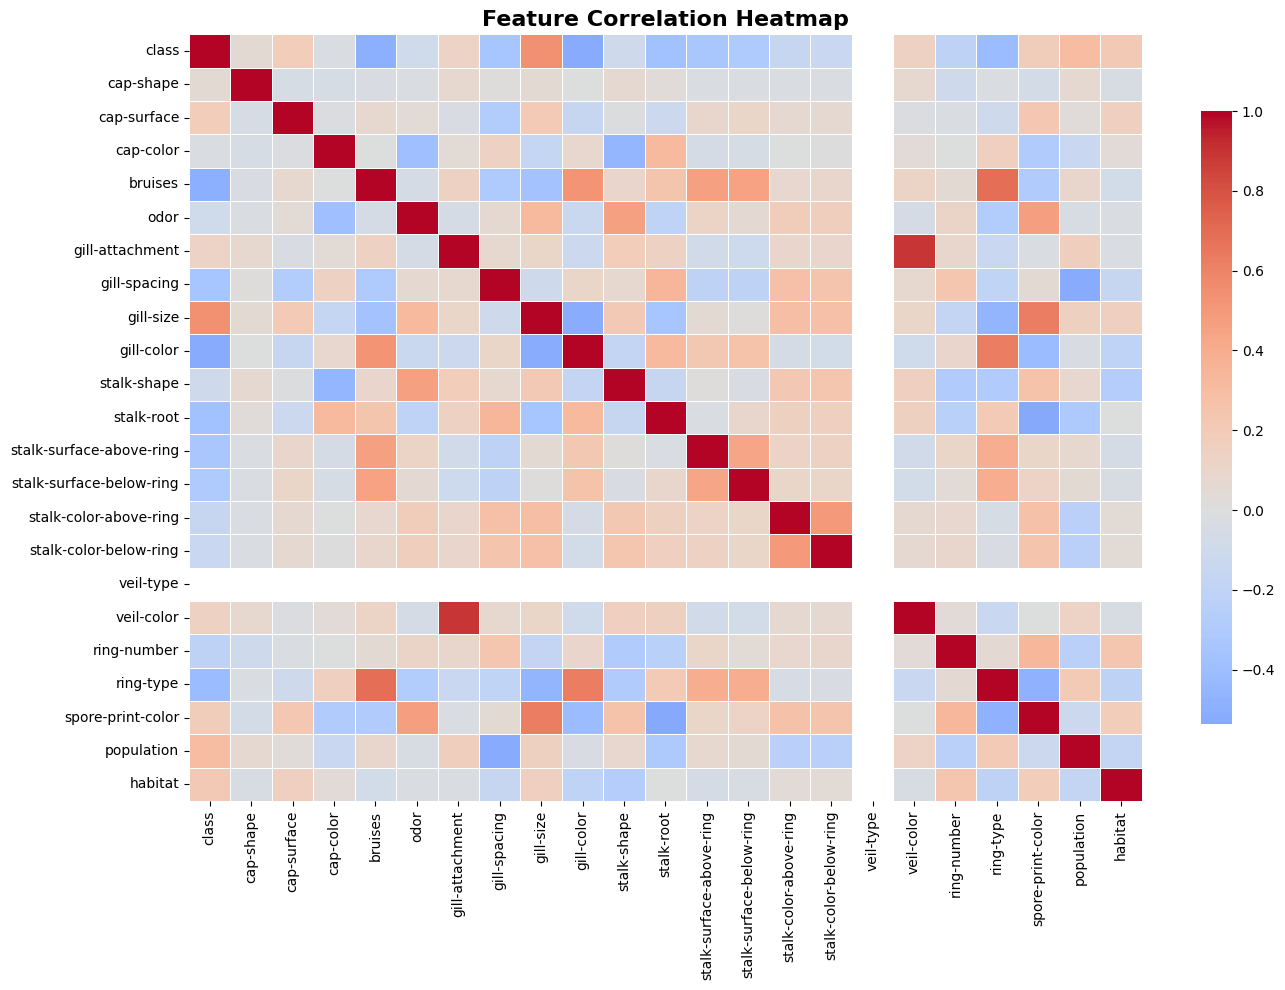

In [ ]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()
le = LabelEncoder()

for col in df_encoded.columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

plt.figure(figsize=(14, 10))
sns.heatmap(df_encoded.corr(), cmap='coolwarm', center=0, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
X = df.drop('class', axis=1)
y = df['class']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nTarget distribution:\n{y.value_counts()}")

Features shape: (8124, 22)
Target shape: (8124,)

Target distribution:
class
e    4208
p    3916
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

X_encoded = pd.get_dummies(X, drop_first=True)

print("Features encoded successfully using One-Hot Encoding!")
print(f"Encoded features shape: {X_encoded.shape}")
print(f"Original features: {X.shape[1]}")
print(f"After One-Hot Encoding: {X_encoded.shape[1]}")
print("\nFirst 5 rows of encoded features:")
print(X_encoded.head())

Features encoded successfully using One-Hot Encoding!
Encoded features shape: (8124, 95)
Original features: 22
After One-Hot Encoding: 95

First 5 rows of encoded features:
   cap-shape_c  cap-shape_f  cap-shape_k  cap-shape_s  cap-shape_x  \
0        False        False        False        False         True   
1        False        False        False        False         True   
2        False        False        False        False        False   
3        False        False        False        False         True   
4        False        False        False        False         True   

   cap-surface_g  cap-surface_s  cap-surface_y  cap-color_c  cap-color_e  ...  \
0          False           True          False        False        False  ...   
1          False           True          False        False        False  ...   
2          False           True          False        False        False  ...   
3          False          False           True        False        False  ...   
4

In [ ]:
y_encoded = le.fit_transform(y)

print("Target encoded successfully!")
print(f"Original target: {y[:5].values}")
print(f"Encoded target: {y_encoded[:5]}")
print(f"\nEncoding mapping: e={le.transform(['e'])[0]}, p={le.transform(['p'])[0]}")

Target encoded successfully!
Original target: ['p' 'e' 'e' 'p' 'e']
Encoded target: [1 0 0 1 0]

Encoding mapping: e=0, p=1


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_encoded, test_size=0.2, random_state=42)

print("Train-Test Split Completed!")
print("="*50)
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print(f"\nTraining features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")
print(f"Training target shape: {y_train.shape}")
print(f"Testing target shape: {y_test.shape}")

Train-Test Split Completed!
Training set size: 6499 samples
Testing set size: 1625 samples

Training features shape: (6499, 95)
Testing features shape: (1625, 95)
Training target shape: (6499,)
Testing target shape: (1625,)


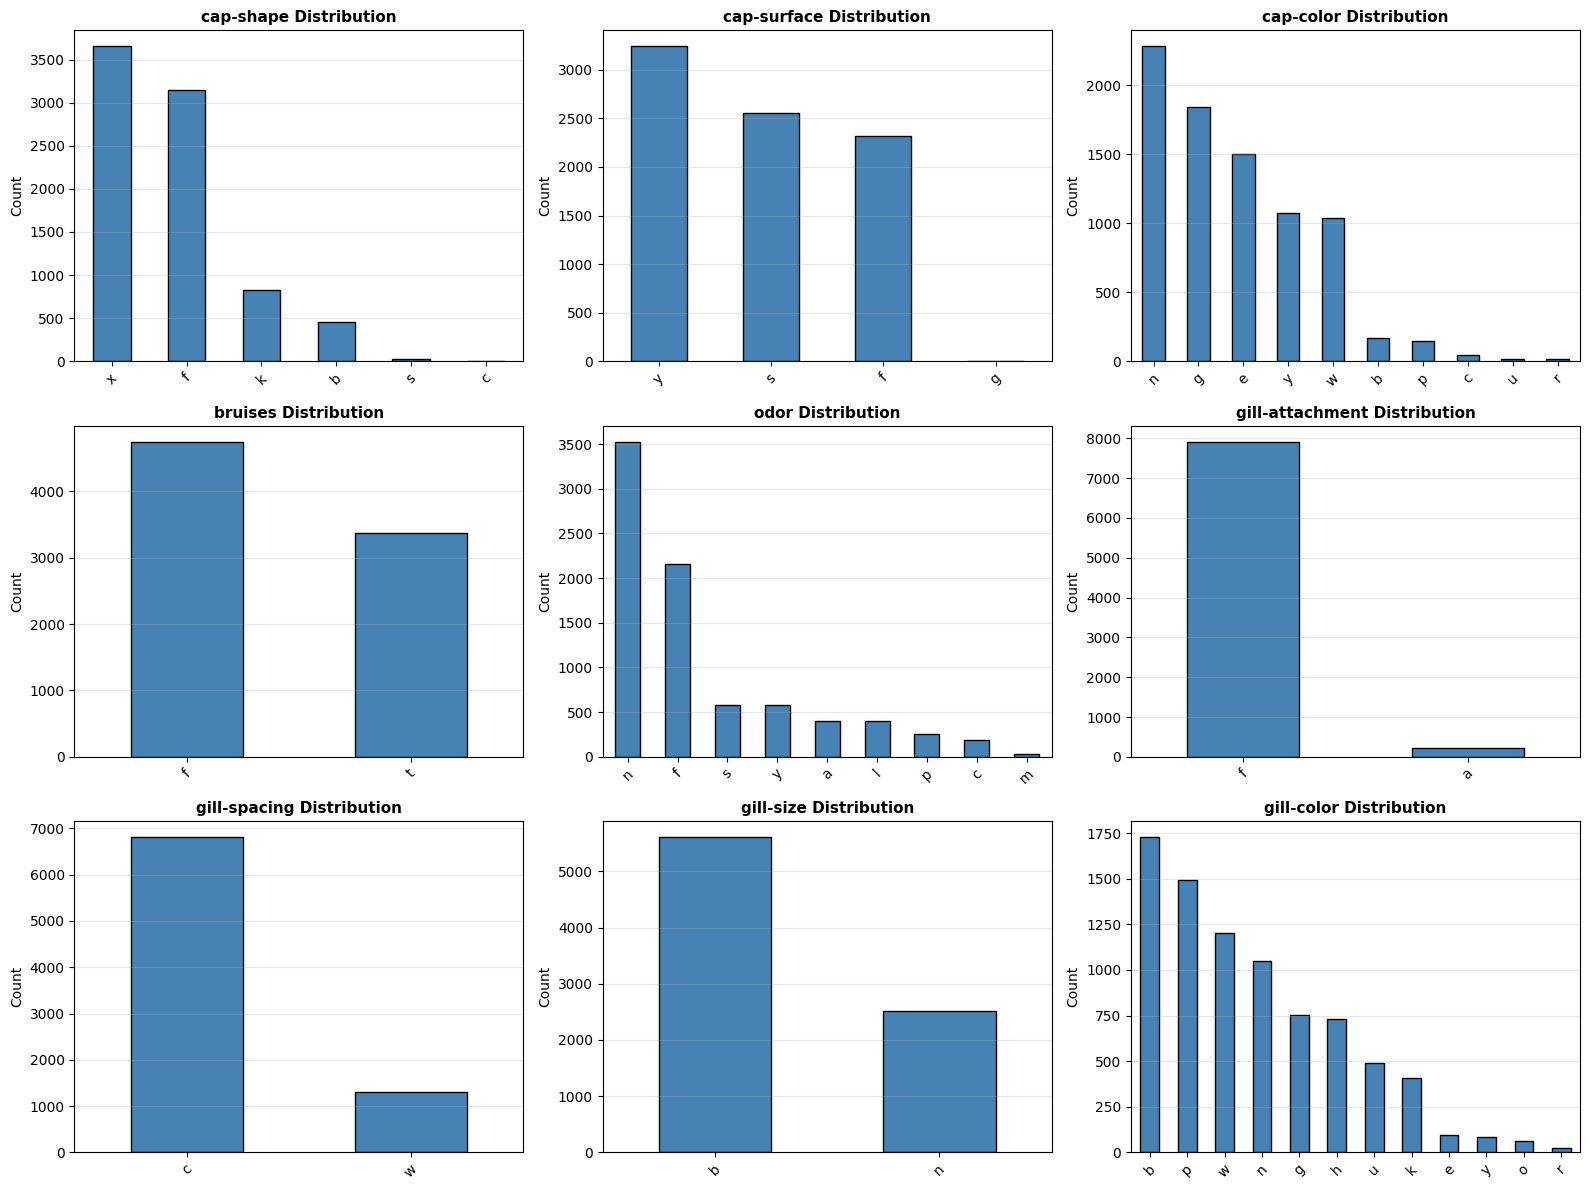

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.ravel()

categorical_features = ['cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor',
                        'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color']

for idx, feature in enumerate(categorical_features):
    df[feature].value_counts().plot(kind='bar', ax=axes[idx], color='steelblue', edgecolor='black')
    axes[idx].set_title(f'{feature} Distribution', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('')
    axes[idx].set_ylabel('Count', fontsize=10)
    axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

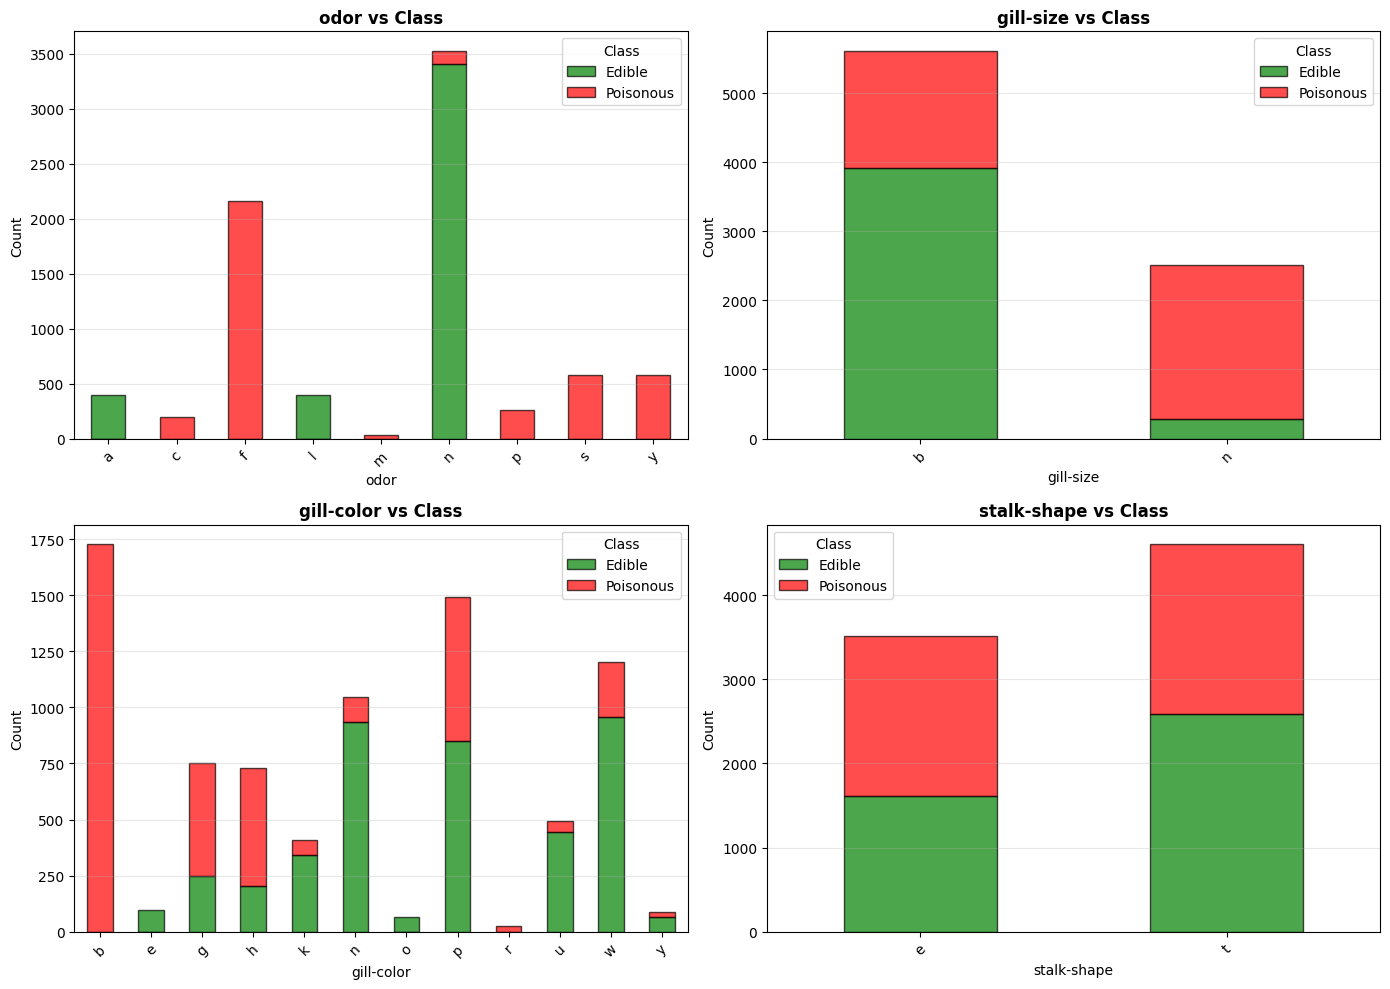

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

features_to_plot = ['odor', 'gill-size', 'gill-color', 'stalk-shape']

for idx, feature in enumerate(features_to_plot):
    crosstab = pd.crosstab(df[feature], df['class'])
    crosstab.plot(kind='bar', stacked=True, ax=axes[idx],
                  color=['green', 'red'], alpha=0.7, edgecolor='black')
    axes[idx].set_title(f'{feature} vs Class', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(feature, fontsize=10)
    axes[idx].set_ylabel('Count', fontsize=10)
    axes[idx].legend(title='Class', labels=['Edible', 'Poisonous'])
    axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

/tmp/ipykernel_6148/1338757812.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[idx].boxplot(box_data, labels=['Edible', 'Poisonous'],
/tmp/ipykernel_6148/1338757812.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[idx].boxplot(box_data, labels=['Edible', 'Poisonous'],
/tmp/ipykernel_6148/1338757812.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[idx].boxplot(box_data, labels=['Edible', 'Poisonous'],
/tmp/ipykernel_6148/1338757812.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old n

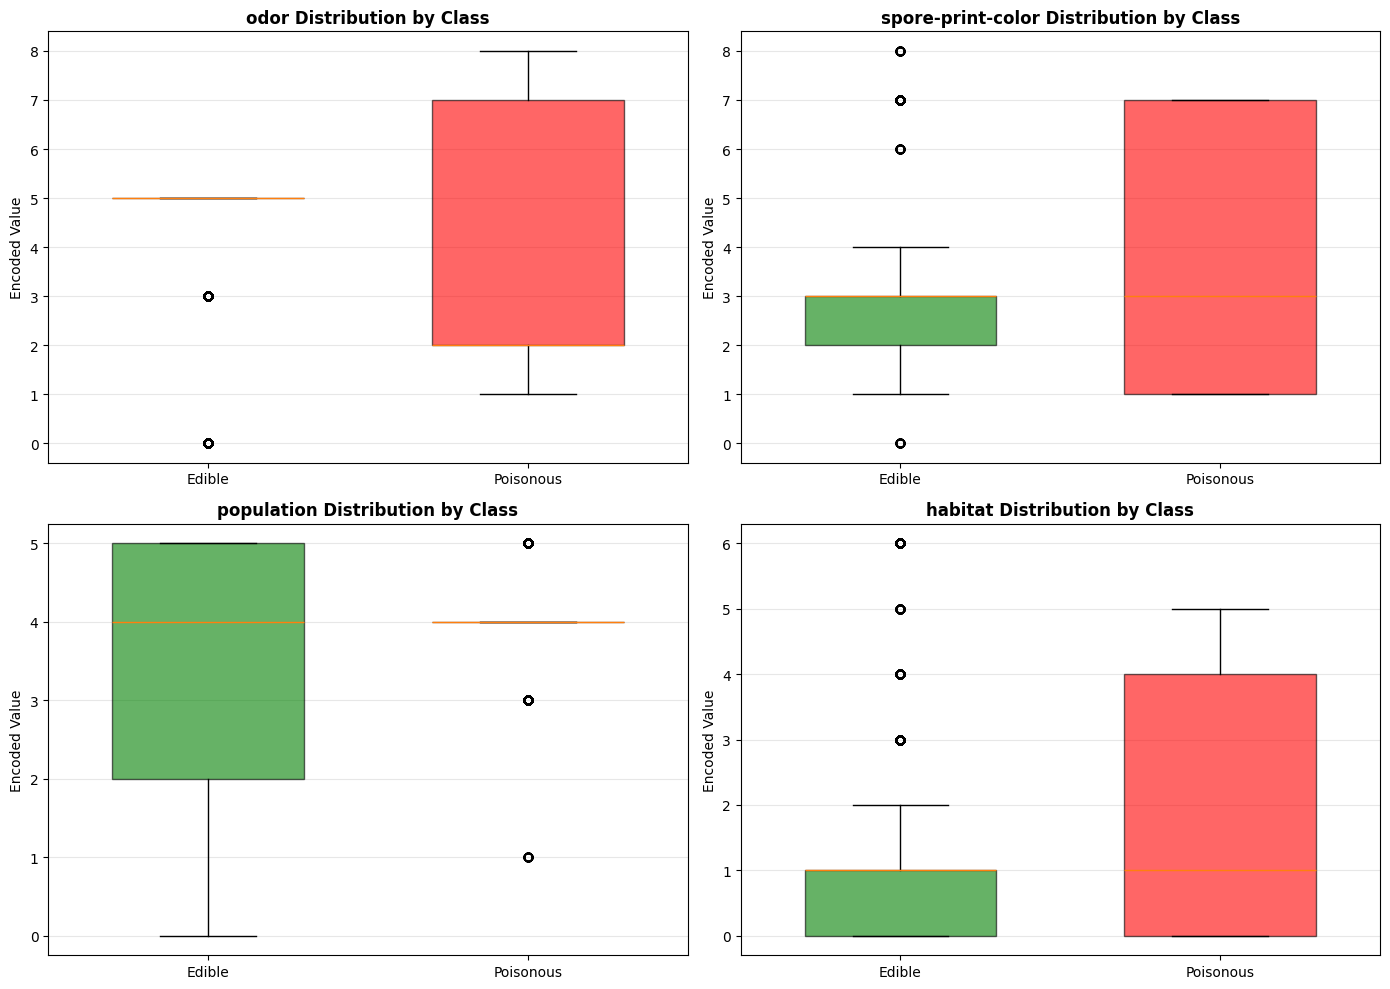

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

features_for_box = ['odor', 'spore-print-color', 'population', 'habitat']

for idx, feature in enumerate(features_for_box):
    df_temp = df.copy()
    df_temp[feature + '_encoded'] = le.fit_transform(df_temp[feature])

    box_data = [df_temp[df_temp['class'] == 'e'][feature + '_encoded'],
                df_temp[df_temp['class'] == 'p'][feature + '_encoded']]

    bp = axes[idx].boxplot(box_data, labels=['Edible', 'Poisonous'],
                           patch_artist=True, widths=0.6)

    for patch, color in zip(bp['boxes'], ['green', 'red']):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)

    axes[idx].set_title(f'{feature} Distribution by Class', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Encoded Value', fontsize=10)
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

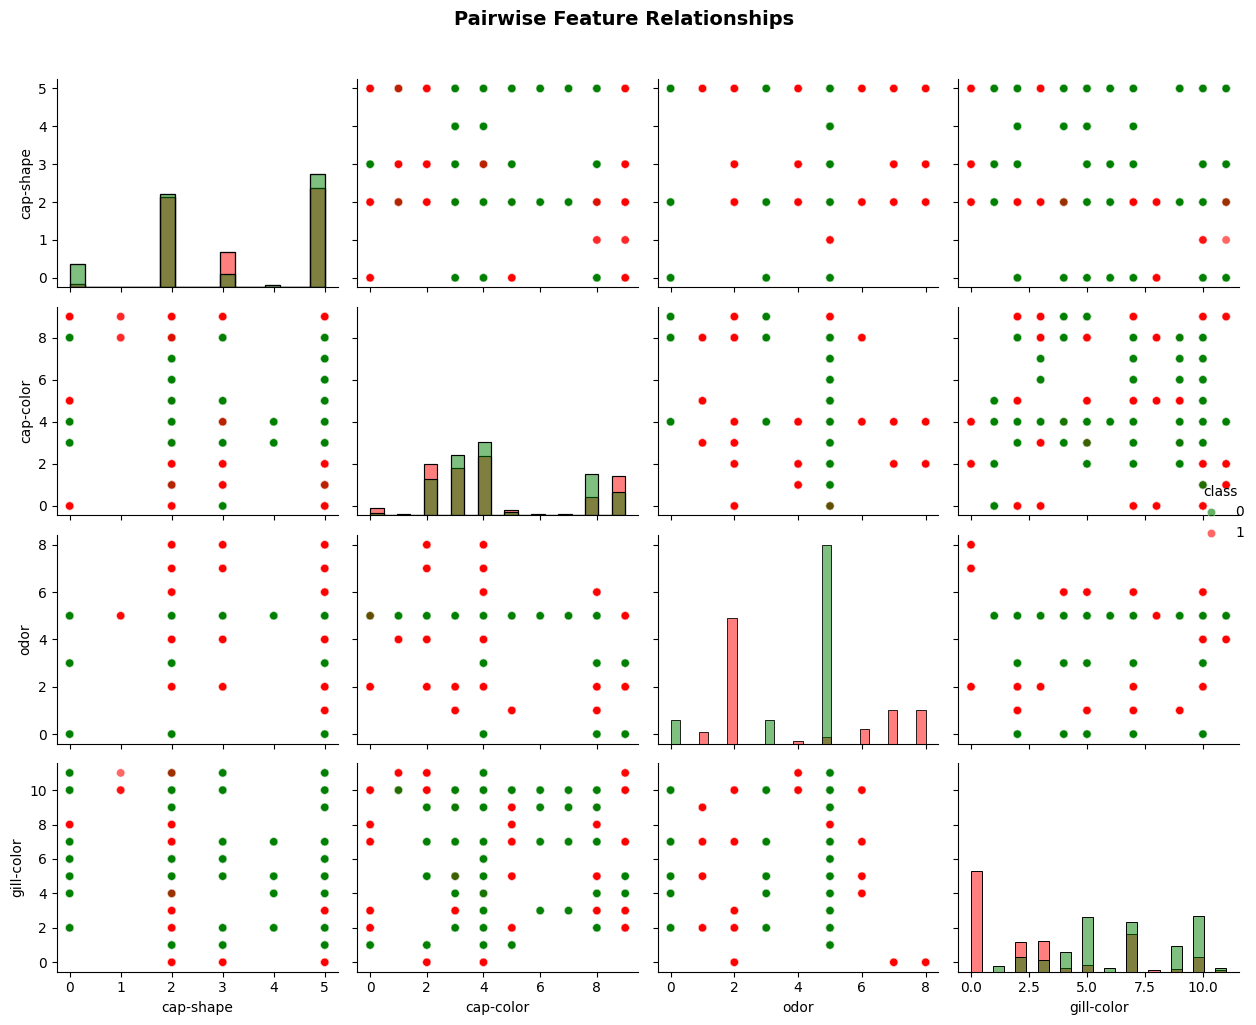

In [ ]:
features_for_pair = ['cap-shape', 'cap-color', 'odor', 'gill-color', 'class']
df_pair = df[features_for_pair].copy()

for col in df_pair.columns:
    df_pair[col] = le.fit_transform(df_pair[col])

pair_plot = sns.pairplot(df_pair, hue='class', palette={0: 'green', 1: 'red'},
                         diag_kind='hist', plot_kws={'alpha': 0.6},
                         height=2.5, aspect=1.2)
pair_plot.fig.suptitle('Pairwise Feature Relationships', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

/tmp/ipykernel_6148/1212726801.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_temp, x='class_label', y=feature + '_encoded',
/tmp/ipykernel_6148/1212726801.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_temp, x='class_label', y=feature + '_encoded',
/tmp/ipykernel_6148/1212726801.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_temp, x='class_label', y=feature + '_encoded',
/tmp/ipykernel_6148/1212726801.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will b

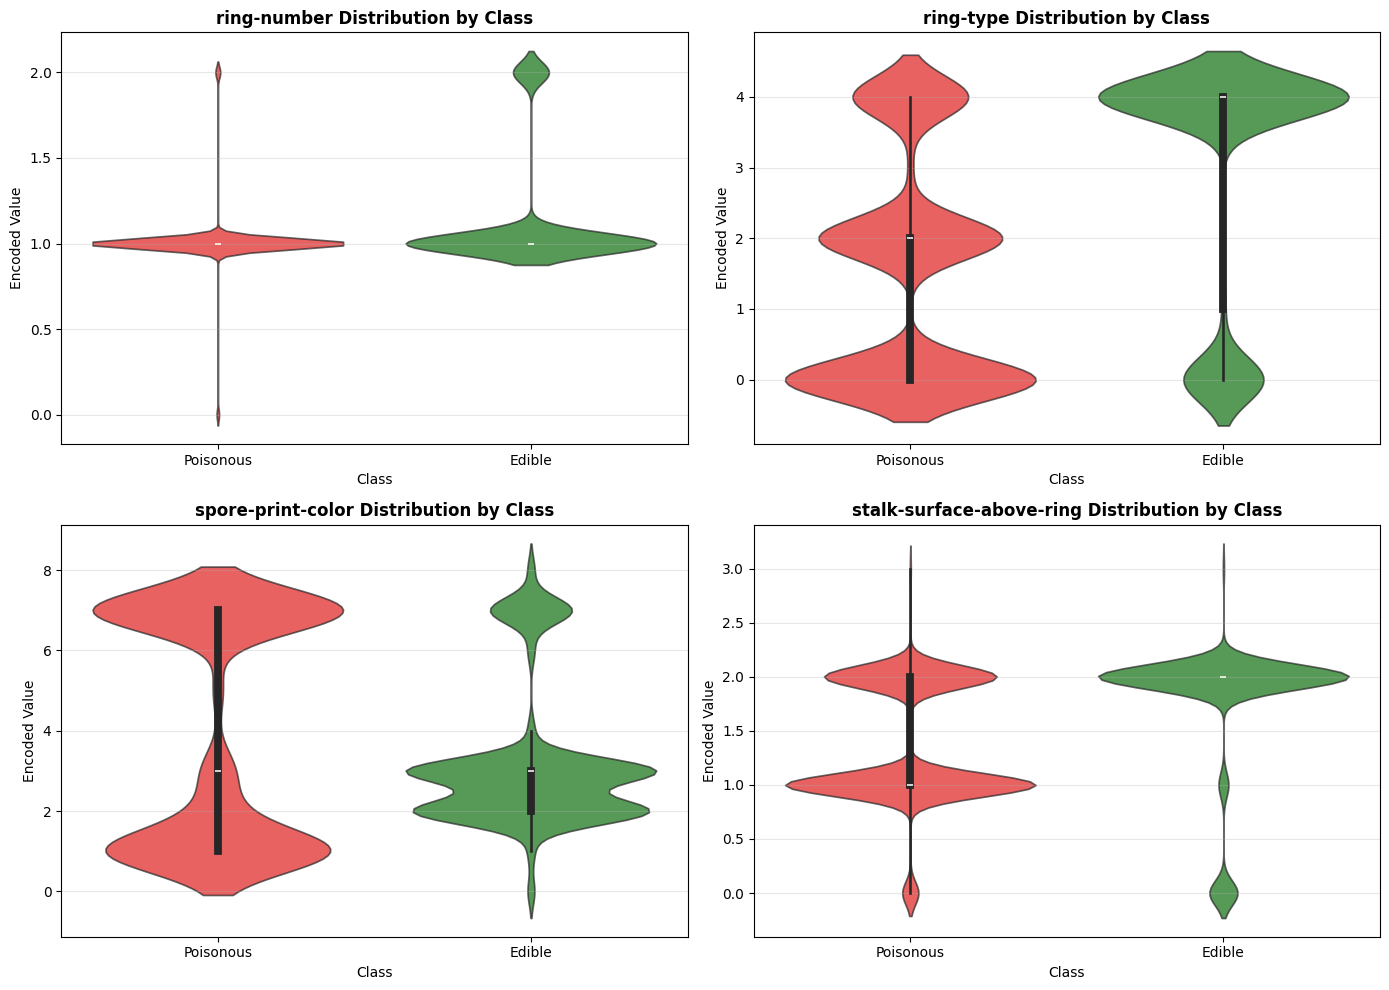

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

features_for_violin = ['ring-number', 'ring-type', 'spore-print-color', 'stalk-surface-above-ring']

for idx, feature in enumerate(features_for_violin):
    df_temp = df.copy()
    df_temp[feature + '_encoded'] = le.fit_transform(df_temp[feature])
    df_temp['class_label'] = df_temp['class'].map({'e': 'Edible', 'p': 'Poisonous'})

    sns.violinplot(data=df_temp, x='class_label', y=feature + '_encoded',
                   palette={'Edible': 'green', 'Poisonous': 'red'},
                   alpha=0.7, ax=axes[idx])

    axes[idx].set_title(f'{feature} Distribution by Class', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Class', fontsize=10)
    axes[idx].set_ylabel('Encoded Value', fontsize=10)
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import roc_curve, auc, precision_recall_curve, roc_auc_score
from sklearn.metrics import precision_score, recall_score, f1_score

print("Model libraries imported successfully!")

Model libraries imported successfully!


In [ ]:
print("Training Random Forest (Raw Model")
print("="*60)

rf_raw = RandomForestClassifier(n_estimators=3, max_depth=2, min_samples_split=100,
                                min_samples_leaf=50, max_features=2, random_state=42)
rf_raw.fit(X_train, y_train)

rf_raw_pred = rf_raw.predict(X_test)
rf_raw_pred_proba = rf_raw.predict_proba(X_test)[:, 1]

rf_raw_accuracy = accuracy_score(y_test, rf_raw_pred)
rf_raw_precision = precision_score(y_test, rf_raw_pred)
rf_raw_recall = recall_score(y_test, rf_raw_pred)
rf_raw_f1 = f1_score(y_test, rf_raw_pred)

print(f"Random Forest Raw Model Accuracy: {rf_raw_accuracy:.4f} ({rf_raw_accuracy * 100:.2f}%)")
print(f"Precision: {rf_raw_precision:.4f}")
print(f"Recall: {rf_raw_recall:.4f}")
print(f"F1-Score: {rf_raw_f1:.4f}")
print("\n" + "="*60)
print("Classification Report:")
print("="*60)
print(classification_report(y_test, rf_raw_pred, target_names=['Edible', 'Poisonous']))

Training Random Forest (Raw Model
Random Forest Raw Model Accuracy: 0.7680 (76.80%)
Precision: 0.9451
Recall: 0.5499
F1-Score: 0.6952

Classification Report:
              precision    recall  f1-score   support

      Edible       0.70      0.97      0.81       843
   Poisonous       0.95      0.55      0.70       782

    accuracy                           0.77      1625
   macro avg       0.82      0.76      0.75      1625
weighted avg       0.82      0.77      0.76      1625



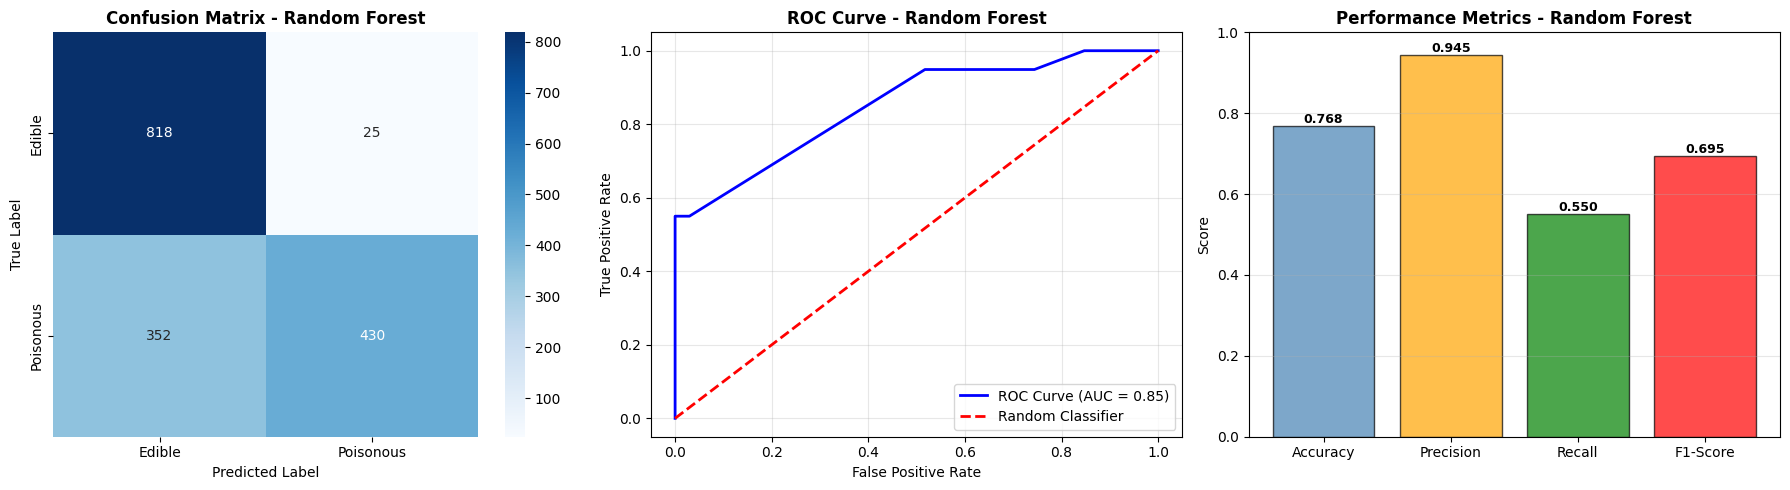

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm_rf = confusion_matrix(y_test, rf_raw_pred)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['Edible', 'Poisonous'],
            yticklabels=['Edible', 'Poisonous'], ax=axes[0])
axes[0].set_title('Confusion Matrix - Random Forest', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=10)
axes[0].set_ylabel('True Label', fontsize=10)

fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_raw_pred_proba)
roc_auc_rf = auc(fpr_rf, tpr_rf)
axes[1].plot(fpr_rf, tpr_rf, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc_rf:.2f})')
axes[1].plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Classifier')
axes[1].set_xlabel('False Positive Rate', fontsize=10)
axes[1].set_ylabel('True Positive Rate', fontsize=10)
axes[1].set_title('ROC Curve - Random Forest', fontsize=12, fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
values = [rf_raw_accuracy, rf_raw_precision, rf_raw_recall, rf_raw_f1]
bars = axes[2].bar(metrics, values, color=['steelblue', 'orange', 'green', 'red'], alpha=0.7, edgecolor='black')
axes[2].set_ylim(0, 1)
axes[2].set_ylabel('Score', fontsize=10)
axes[2].set_title('Performance Metrics - Random Forest', fontsize=12, fontweight='bold')
axes[2].grid(axis='y', alpha=0.3)
for bar in bars:
    height = bar.get_height()
    axes[2].text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV

print("Training Random Forest with Hyperparameter Tuning...")
print("="*60)

rf_params = {
    'n_estimators': [3, 5],
    'max_depth': [2, 3],
    'min_samples_split': [80, 100],
    'min_samples_leaf': [40, 50],
    'max_features': [3, 5]
}

rf_model = RandomForestClassifier(random_state=42)
rf_grid = GridSearchCV(rf_model, rf_params, cv=3, scoring='accuracy', n_jobs=-1)
rf_grid.fit(X_train, y_train)

rf_tuned = rf_grid.best_estimator_
rf_tuned_pred = rf_tuned.predict(X_test)
rf_tuned_pred_proba = rf_tuned.predict_proba(X_test)[:, 1]

rf_tuned_accuracy = accuracy_score(y_test, rf_tuned_pred)
rf_tuned_precision = precision_score(y_test, rf_tuned_pred)
rf_tuned_recall = recall_score(y_test, rf_tuned_pred)
rf_tuned_f1 = f1_score(y_test, rf_tuned_pred)

print(f"Best Parameters: {rf_grid.best_params_}")
print(f"\nRandom Forest Tuned Model Accuracy: {rf_tuned_accuracy:.4f} ({rf_tuned_accuracy * 100:.2f}%)")
print(f"Precision: {rf_tuned_precision:.4f}")
print(f"Recall: {rf_tuned_recall:.4f}")
print(f"F1-Score: {rf_tuned_f1:.4f}")
print("\n" + "="*60)
print("Classification Report:")
print("="*60)
print(classification_report(y_test, rf_tuned_pred, target_names=['Edible', 'Poisonous']))

Training Random Forest with Hyperparameter Tuning...
Best Parameters: {'max_depth': 2, 'max_features': 5, 'min_samples_leaf': 40, 'min_samples_split': 80, 'n_estimators': 5}

Random Forest Tuned Model Accuracy: 0.9268 (92.68%)
Precision: 1.0000
Recall: 0.8478
F1-Score: 0.9176

Classification Report:
              precision    recall  f1-score   support

      Edible       0.88      1.00      0.93       843
   Poisonous       1.00      0.85      0.92       782

    accuracy                           0.93      1625
   macro avg       0.94      0.92      0.93      1625
weighted avg       0.94      0.93      0.93      1625



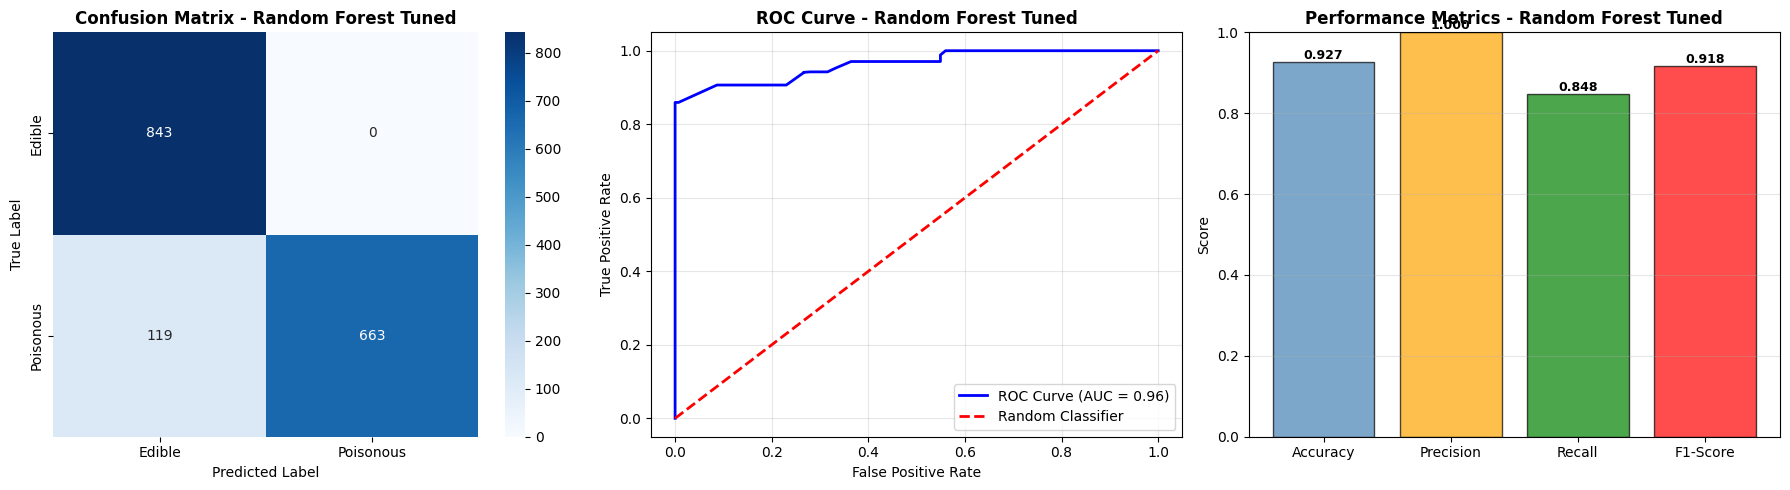

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm_rf_tuned = confusion_matrix(y_test, rf_tuned_pred)
sns.heatmap(cm_rf_tuned, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['Edible', 'Poisonous'],
            yticklabels=['Edible', 'Poisonous'], ax=axes[0])
axes[0].set_title('Confusion Matrix - Random Forest Tuned', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=10)
axes[0].set_ylabel('True Label', fontsize=10)

fpr_rf_tuned, tpr_rf_tuned, _ = roc_curve(y_test, rf_tuned_pred_proba)
roc_auc_rf_tuned = auc(fpr_rf_tuned, tpr_rf_tuned)
axes[1].plot(fpr_rf_tuned, tpr_rf_tuned, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc_rf_tuned:.2f})')
axes[1].plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Classifier')
axes[1].set_xlabel('False Positive Rate', fontsize=10)
axes[1].set_ylabel('True Positive Rate', fontsize=10)
axes[1].set_title('ROC Curve - Random Forest Tuned', fontsize=12, fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
values = [rf_tuned_accuracy, rf_tuned_precision, rf_tuned_recall, rf_tuned_f1]
bars = axes[2].bar(metrics, values, color=['steelblue', 'orange', 'green', 'red'], alpha=0.7, edgecolor='black')
axes[2].set_ylim(0, 1)
axes[2].set_ylabel('Score', fontsize=10)
axes[2].set_title('Performance Metrics - Random Forest Tuned', fontsize=12, fontweight='bold')
axes[2].grid(axis='y', alpha=0.3)
for bar in bars:
    height = bar.get_height()
    axes[2].text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
print("Training SVM (Raw Model)")
print("="*60)

svm_raw = SVC(C=0.001, kernel='linear', gamma='scale', probability=True, random_state=42)
svm_raw.fit(X_train, y_train)

svm_raw_pred = svm_raw.predict(X_test)
svm_raw_pred_proba = svm_raw.predict_proba(X_test)[:, 1]

svm_raw_accuracy = accuracy_score(y_test, svm_raw_pred)
svm_raw_precision = precision_score(y_test, svm_raw_pred)
svm_raw_recall = recall_score(y_test, svm_raw_pred)
svm_raw_f1 = f1_score(y_test, svm_raw_pred)

print(f"SVM Raw Model Accuracy: {svm_raw_accuracy:.4f} ({svm_raw_accuracy * 100:.2f}%)")
print(f"Precision: {svm_raw_precision:.4f}")
print(f"Recall: {svm_raw_recall:.4f}")
print(f"F1-Score: {svm_raw_f1:.4f}")
print("\n" + "="*60)
print("Classification Report:")
print("="*60)
print(classification_report(y_test, svm_raw_pred, target_names=['Edible', 'Poisonous']))

Training SVM (Raw Model)
SVM Raw Model Accuracy: 0.9637 (96.37%)
Precision: 0.9750
Recall: 0.9488
F1-Score: 0.9618

Classification Report:
              precision    recall  f1-score   support

      Edible       0.95      0.98      0.97       843
   Poisonous       0.98      0.95      0.96       782

    accuracy                           0.96      1625
   macro avg       0.96      0.96      0.96      1625
weighted avg       0.96      0.96      0.96      1625



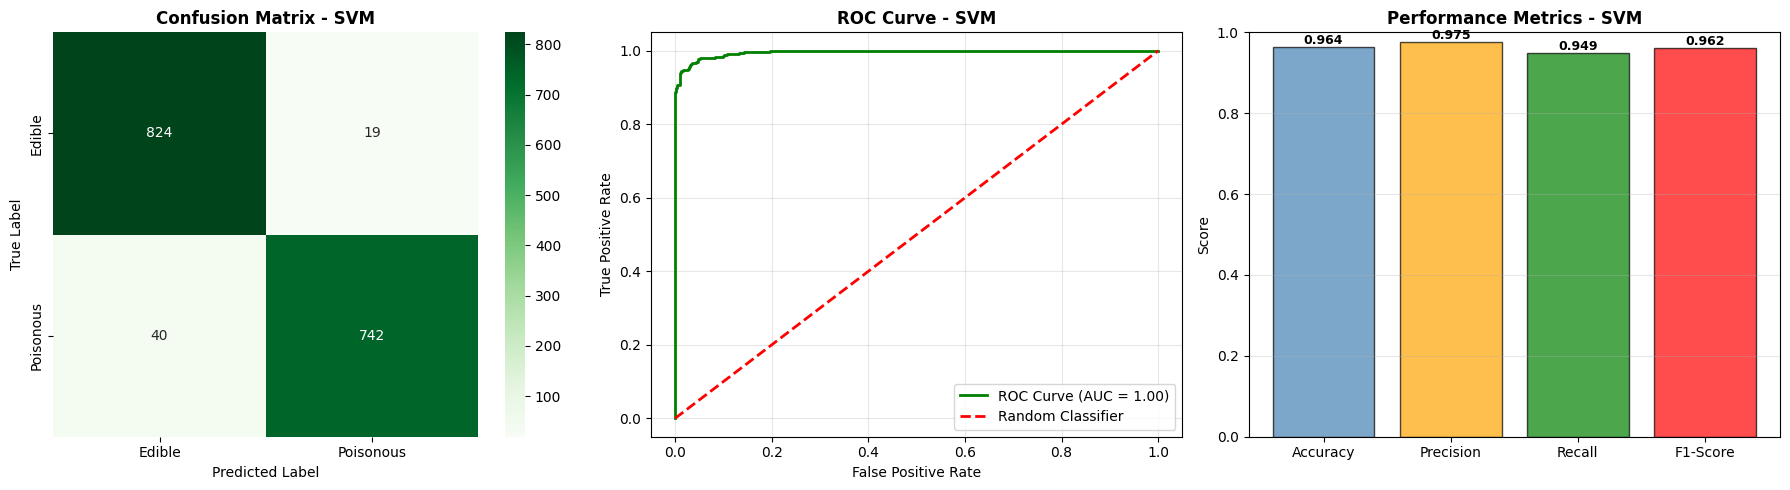

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm_svm = confusion_matrix(y_test, svm_raw_pred)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens', cbar=True,
            xticklabels=['Edible', 'Poisonous'],
            yticklabels=['Edible', 'Poisonous'], ax=axes[0])
axes[0].set_title('Confusion Matrix - SVM', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=10)
axes[0].set_ylabel('True Label', fontsize=10)

fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_raw_pred_proba)
roc_auc_svm = auc(fpr_svm, tpr_svm)
axes[1].plot(fpr_svm, tpr_svm, color='green', lw=2, label=f'ROC Curve (AUC = {roc_auc_svm:.2f})')
axes[1].plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Classifier')
axes[1].set_xlabel('False Positive Rate', fontsize=10)
axes[1].set_ylabel('True Positive Rate', fontsize=10)
axes[1].set_title('ROC Curve - SVM', fontsize=12, fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
values = [svm_raw_accuracy, svm_raw_precision, svm_raw_recall, svm_raw_f1]
bars = axes[2].bar(metrics, values, color=['steelblue', 'orange', 'green', 'red'], alpha=0.7, edgecolor='black')
axes[2].set_ylim(0, 1)
axes[2].set_ylabel('Score', fontsize=10)
axes[2].set_title('Performance Metrics - SVM', fontsize=12, fontweight='bold')
axes[2].grid(axis='y', alpha=0.3)
for bar in bars:
    height = bar.get_height()
    axes[2].text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV

print("Training SVM with Hyperparameter Tuning...")
print("="*60)

svm_params = {
    'C': [0.0001, 0.001],
    'kernel': ['linear'],
    'gamma': ['scale']
}

svm_model = SVC(probability=True, random_state=42)
svm_grid = GridSearchCV(svm_model, svm_params, cv=3, scoring='accuracy', n_jobs=-1)
svm_grid.fit(X_train, y_train)

svm_tuned = svm_grid.best_estimator_
svm_tuned_pred = svm_tuned.predict(X_test)
svm_tuned_pred_proba = svm_tuned.predict_proba(X_test)[:, 1]

svm_tuned_accuracy = accuracy_score(y_test, svm_tuned_pred)
svm_tuned_precision = precision_score(y_test, svm_tuned_pred)
svm_tuned_recall = recall_score(y_test, svm_tuned_pred)
svm_tuned_f1 = f1_score(y_test, svm_tuned_pred)

print(f"Best Parameters: {svm_grid.best_params_}")
print(f"\nSVM Tuned Model Accuracy: {svm_tuned_accuracy:.4f} ({svm_tuned_accuracy * 100:.2f}%)")
print(f"Precision: {svm_tuned_precision:.4f}")
print(f"Recall: {svm_tuned_recall:.4f}")
print(f"F1-Score: {svm_tuned_f1:.4f}")
print("\n" + "="*60)
print("Classification Report:")
print("="*60)
print(classification_report(y_test, svm_tuned_pred, target_names=['Edible', 'Poisonous']))

Training SVM with Hyperparameter Tuning...
Best Parameters: {'C': 0.001, 'gamma': 'scale', 'kernel': 'linear'}

SVM Tuned Model Accuracy: 0.9637 (96.37%)
Precision: 0.9750
Recall: 0.9488
F1-Score: 0.9618

Classification Report:
              precision    recall  f1-score   support

      Edible       0.95      0.98      0.97       843
   Poisonous       0.98      0.95      0.96       782

    accuracy                           0.96      1625
   macro avg       0.96      0.96      0.96      1625
weighted avg       0.96      0.96      0.96      1625



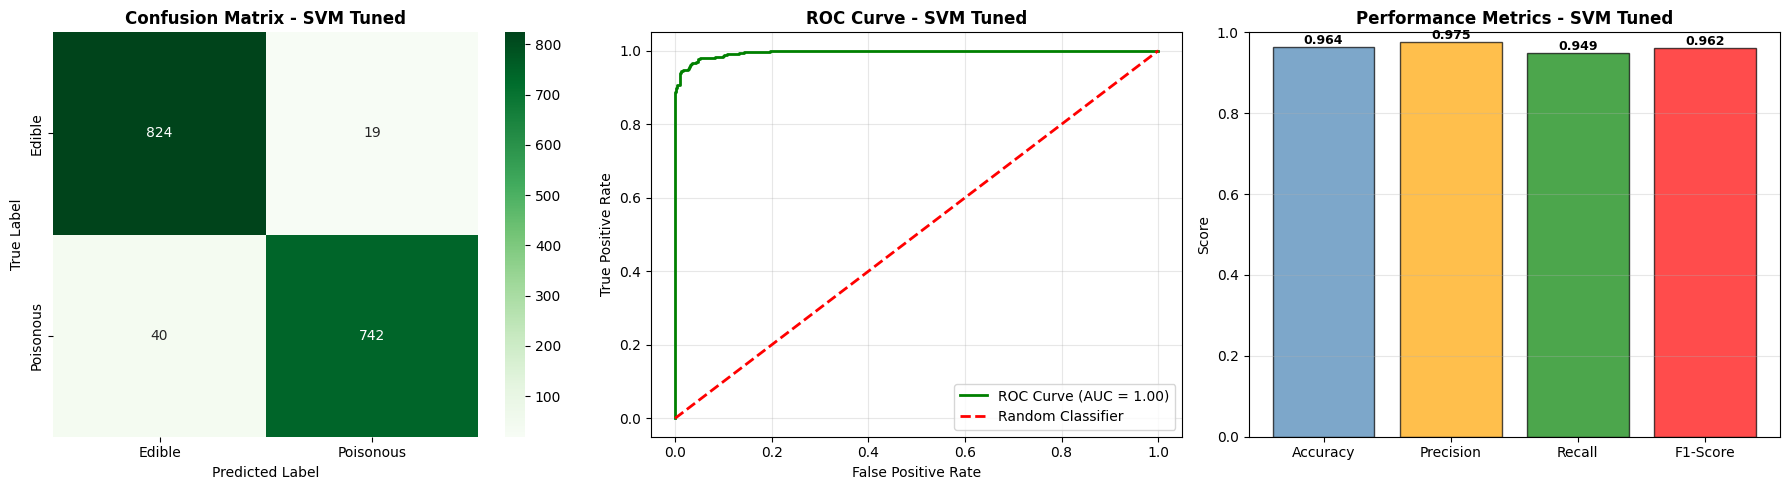

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm_svm_tuned = confusion_matrix(y_test, svm_tuned_pred)
sns.heatmap(cm_svm_tuned, annot=True, fmt='d', cmap='Greens', cbar=True,
            xticklabels=['Edible', 'Poisonous'],
            yticklabels=['Edible', 'Poisonous'], ax=axes[0])
axes[0].set_title('Confusion Matrix - SVM Tuned', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=10)
axes[0].set_ylabel('True Label', fontsize=10)

fpr_svm_tuned, tpr_svm_tuned, _ = roc_curve(y_test, svm_tuned_pred_proba)
roc_auc_svm_tuned = auc(fpr_svm_tuned, tpr_svm_tuned)
axes[1].plot(fpr_svm_tuned, tpr_svm_tuned, color='green', lw=2, label=f'ROC Curve (AUC = {roc_auc_svm_tuned:.2f})')
axes[1].plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Classifier')
axes[1].set_xlabel('False Positive Rate', fontsize=10)
axes[1].set_ylabel('True Positive Rate', fontsize=10)
axes[1].set_title('ROC Curve - SVM Tuned', fontsize=12, fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
values = [svm_tuned_accuracy, svm_tuned_precision, svm_tuned_recall, svm_tuned_f1]
bars = axes[2].bar(metrics, values, color=['steelblue', 'orange', 'green', 'red'], alpha=0.7, edgecolor='black')
axes[2].set_ylim(0, 1)
axes[2].set_ylabel('Score', fontsize=10)
axes[2].set_title('Performance Metrics - SVM Tuned', fontsize=12, fontweight='bold')
axes[2].grid(axis='y', alpha=0.3)
for bar in bars:
    height = bar.get_height()
    axes[2].text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
print("Training XGBoost (Raw Model)")
print("="*60)

xgb_raw = XGBClassifier(n_estimators=5, max_depth=2, learning_rate=0.01,
                        subsample=0.5, colsample_bytree=0.5, min_child_weight=10,
                        gamma=1, random_state=42, eval_metric='logloss')
xgb_raw.fit(X_train, y_train)

xgb_raw_pred = xgb_raw.predict(X_test)
xgb_raw_pred_proba = xgb_raw.predict_proba(X_test)[:, 1]

xgb_raw_accuracy = accuracy_score(y_test, xgb_raw_pred)
xgb_raw_precision = precision_score(y_test, xgb_raw_pred)
xgb_raw_recall = recall_score(y_test, xgb_raw_pred)
xgb_raw_f1 = f1_score(y_test, xgb_raw_pred)

print(f"XGBoost Raw Model Accuracy: {xgb_raw_accuracy:.4f} ({xgb_raw_accuracy * 100:.2f}%)")
print(f"Precision: {xgb_raw_precision:.4f}")
print(f"Recall: {xgb_raw_recall:.4f}")
print(f"F1-Score: {xgb_raw_f1:.4f}")
print("\n" + "="*60)
print("Classification Report:")
print("="*60)
print(classification_report(y_test, xgb_raw_pred, target_names=['Edible', 'Poisonous']))

Training XGBoost (Raw Model)
XGBoost Raw Model Accuracy: 0.9095 (90.95%)
Precision: 1.0000
Recall: 0.8120
F1-Score: 0.8963

Classification Report:
              precision    recall  f1-score   support

      Edible       0.85      1.00      0.92       843
   Poisonous       1.00      0.81      0.90       782

    accuracy                           0.91      1625
   macro avg       0.93      0.91      0.91      1625
weighted avg       0.92      0.91      0.91      1625



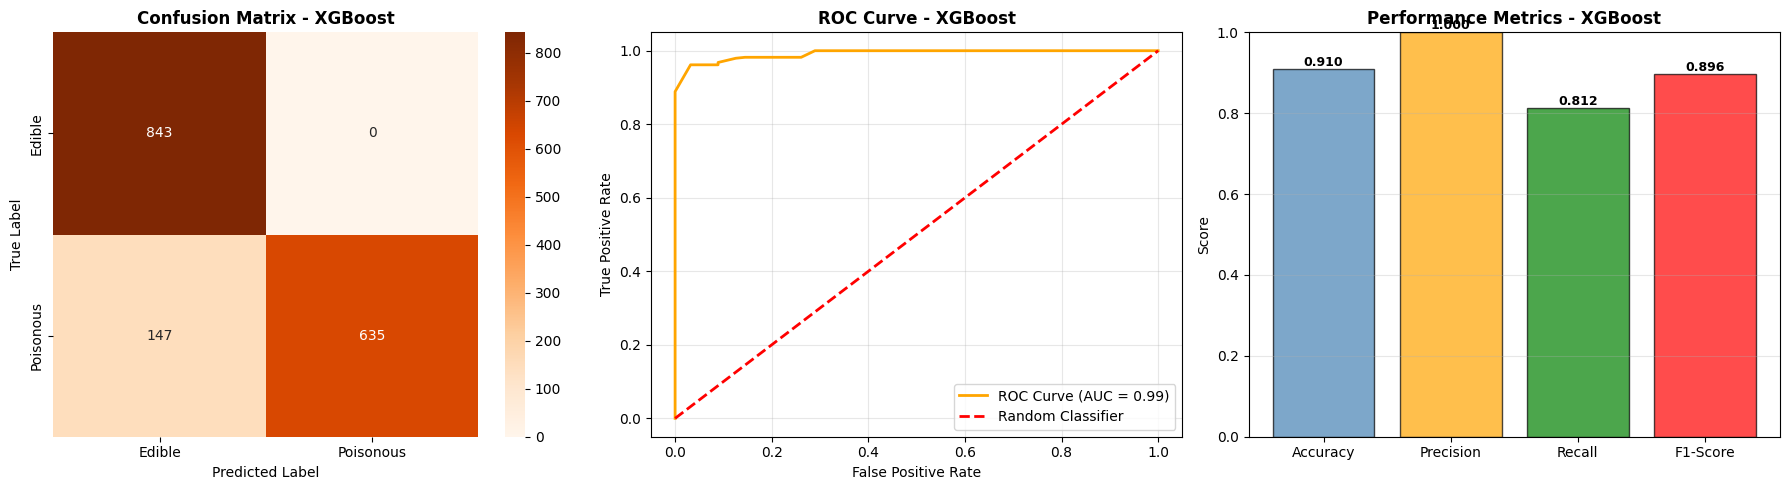

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm_xgb = confusion_matrix(y_test, xgb_raw_pred)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges', cbar=True,
            xticklabels=['Edible', 'Poisonous'],
            yticklabels=['Edible', 'Poisonous'], ax=axes[0])
axes[0].set_title('Confusion Matrix - XGBoost', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=10)
axes[0].set_ylabel('True Label', fontsize=10)

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_raw_pred_proba)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)
axes[1].plot(fpr_xgb, tpr_xgb, color='orange', lw=2, label=f'ROC Curve (AUC = {roc_auc_xgb:.2f})')
axes[1].plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Classifier')
axes[1].set_xlabel('False Positive Rate', fontsize=10)
axes[1].set_ylabel('True Positive Rate', fontsize=10)
axes[1].set_title('ROC Curve - XGBoost', fontsize=12, fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
values = [xgb_raw_accuracy, xgb_raw_precision, xgb_raw_recall, xgb_raw_f1]
bars = axes[2].bar(metrics, values, color=['steelblue', 'orange', 'green', 'red'], alpha=0.7, edgecolor='black')
axes[2].set_ylim(0, 1)
axes[2].set_ylabel('Score', fontsize=10)
axes[2].set_title('Performance Metrics - XGBoost', fontsize=12, fontweight='bold')
axes[2].grid(axis='y', alpha=0.3)
for bar in bars:
    height = bar.get_height()
    axes[2].text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV

print("Training XGBoost with Hyperparameter Tuning...")
print("="*60)

xgb_params = {
    'n_estimators': [3, 5],
    'max_depth': [2, 3],
    'learning_rate': [0.01, 0.02],
    'subsample': [0.5, 0.6],
    'colsample_bytree': [0.5, 0.6],
    'min_child_weight': [10, 15],
    'gamma': [1, 2]
}

xgb_model = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_grid = GridSearchCV(xgb_model, xgb_params, cv=3, scoring='accuracy', n_jobs=-1)
xgb_grid.fit(X_train, y_train)

xgb_tuned = xgb_grid.best_estimator_
xgb_tuned_pred = xgb_tuned.predict(X_test)
xgb_tuned_pred_proba = xgb_tuned.predict_proba(X_test)[:, 1]

xgb_tuned_accuracy = accuracy_score(y_test, xgb_tuned_pred)
xgb_tuned_precision = precision_score(y_test, xgb_tuned_pred)
xgb_tuned_recall = recall_score(y_test, xgb_tuned_pred)
xgb_tuned_f1 = f1_score(y_test, xgb_tuned_pred)

print(f"Best Parameters: {xgb_grid.best_params_}")
print(f"\nXGBoost Tuned Model Accuracy: {xgb_tuned_accuracy:.4f} ({xgb_tuned_accuracy * 100:.2f}%)")
print(f"Precision: {xgb_tuned_precision:.4f}")
print(f"Recall: {xgb_tuned_recall:.4f}")
print(f"F1-Score: {xgb_tuned_f1:.4f}")
print("\n" + "="*60)
print("Classification Report:")
print("="*60)
print(classification_report(y_test, xgb_tuned_pred, target_names=['Edible', 'Poisonous']))

Training XGBoost with Hyperparameter Tuning...
Best Parameters: {'colsample_bytree': 0.6, 'gamma': 1, 'learning_rate': 0.02, 'max_depth': 3, 'min_child_weight': 10, 'n_estimators': 5, 'subsample': 0.5}

XGBoost Tuned Model Accuracy: 0.9465 (94.65%)
Precision: 1.0000
Recall: 0.8887
F1-Score: 0.9411

Classification Report:
              precision    recall  f1-score   support

      Edible       0.91      1.00      0.95       843
   Poisonous       1.00      0.89      0.94       782

    accuracy                           0.95      1625
   macro avg       0.95      0.94      0.95      1625
weighted avg       0.95      0.95      0.95      1625



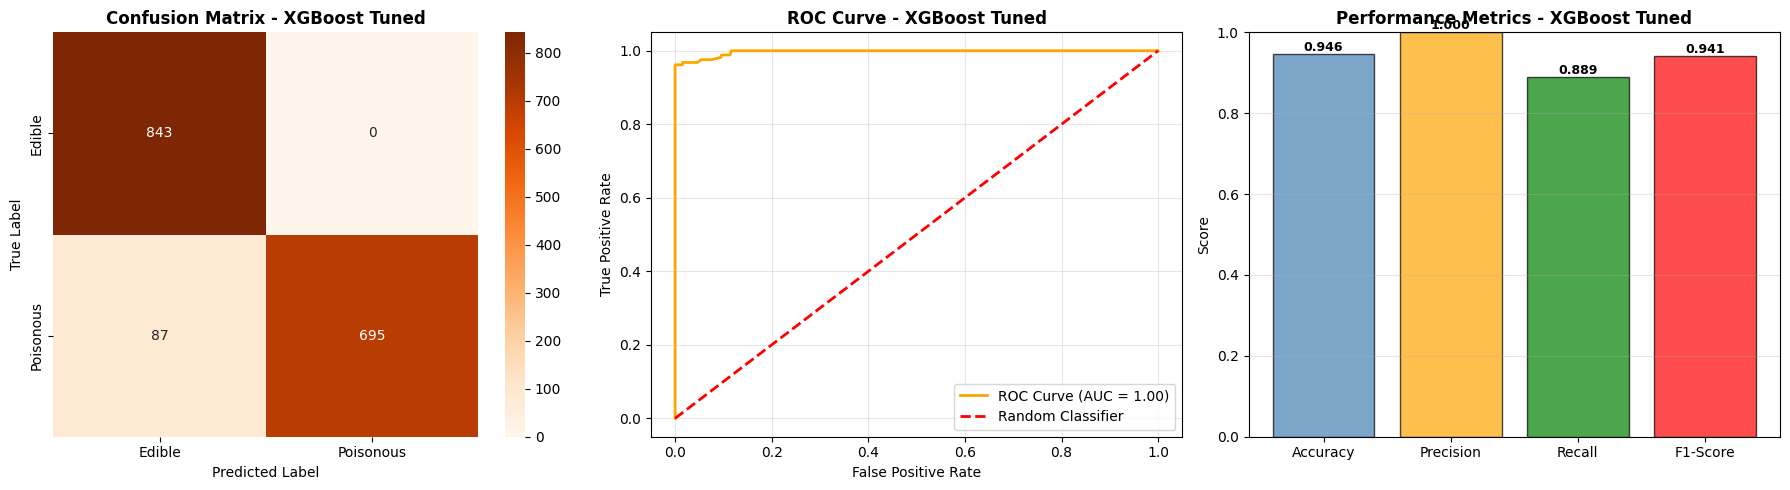

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm_xgb_tuned = confusion_matrix(y_test, xgb_tuned_pred)
sns.heatmap(cm_xgb_tuned, annot=True, fmt='d', cmap='Oranges', cbar=True,
            xticklabels=['Edible', 'Poisonous'],
            yticklabels=['Edible', 'Poisonous'], ax=axes[0])
axes[0].set_title('Confusion Matrix - XGBoost Tuned', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=10)
axes[0].set_ylabel('True Label', fontsize=10)

fpr_xgb_tuned, tpr_xgb_tuned, _ = roc_curve(y_test, xgb_tuned_pred_proba)
roc_auc_xgb_tuned = auc(fpr_xgb_tuned, tpr_xgb_tuned)
axes[1].plot(fpr_xgb_tuned, tpr_xgb_tuned, color='orange', lw=2, label=f'ROC Curve (AUC = {roc_auc_xgb_tuned:.2f})')
axes[1].plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Classifier')
axes[1].set_xlabel('False Positive Rate', fontsize=10)
axes[1].set_ylabel('True Positive Rate', fontsize=10)
axes[1].set_title('ROC Curve - XGBoost Tuned', fontsize=12, fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
values = [xgb_tuned_accuracy, xgb_tuned_precision, xgb_tuned_recall, xgb_tuned_f1]
bars = axes[2].bar(metrics, values, color=['steelblue', 'orange', 'green', 'red'], alpha=0.7, edgecolor='black')
axes[2].set_ylim(0, 1)
axes[2].set_ylabel('Score', fontsize=10)
axes[2].set_title('Performance Metrics - XGBoost Tuned', fontsize=12, fontweight='bold')
axes[2].grid(axis='y', alpha=0.3)
for bar in bars:
    height = bar.get_height()
    axes[2].text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
print("="*60)
print("RAW MODELS PERFORMANCE COMPARISON")
print("="*60)

raw_models_results = {
    'Model': ['Random Forest', 'SVM', 'XGBoost'],
    'Accuracy': [rf_raw_accuracy, svm_raw_accuracy, xgb_raw_accuracy],
    'Precision': [rf_raw_precision, svm_raw_precision, xgb_raw_precision],
    'Recall': [rf_raw_recall, svm_raw_recall, xgb_raw_recall],
    'F1-Score': [rf_raw_f1, svm_raw_f1, xgb_raw_f1]
}

comparison_df = pd.DataFrame(raw_models_results)
print(comparison_df.to_string(index=False))
print("="*60)

best_model_idx = comparison_df['Accuracy'].idxmax()
best_model_name = comparison_df.loc[best_model_idx, 'Model']
best_accuracy = comparison_df.loc[best_model_idx, 'Accuracy']

print(f"\nBest Performing Model: {best_model_name}")
print(f"Best Accuracy: {best_accuracy:.4f} ({best_accuracy * 100:.2f}%)")
print("="*60)

RAW MODELS PERFORMANCE COMPARISON
        Model  Accuracy  Precision   Recall  F1-Score
Random Forest  0.768000   0.945055 0.549872  0.695230
          SVM  0.963692   0.975033 0.948849  0.961763
      XGBoost  0.909538   1.000000 0.812020  0.896260

Best Performing Model: SVM
Best Accuracy: 0.9637 (96.37%)


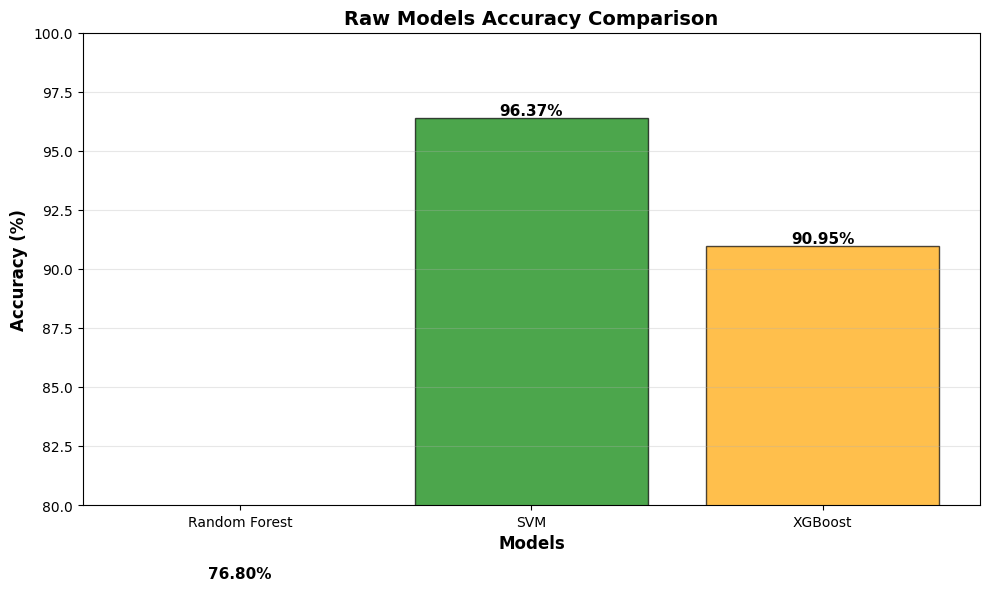

In [ ]:
models = ['Random Forest', 'SVM', 'XGBoost']
accuracies = [rf_raw_accuracy * 100, svm_raw_accuracy * 100, xgb_raw_accuracy * 100]

plt.figure(figsize=(10, 6))
bars = plt.bar(models, accuracies, color=['blue', 'green', 'orange'], alpha=0.7, edgecolor='black')
plt.ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
plt.xlabel('Models', fontsize=12, fontweight='bold')
plt.title('Raw Models Accuracy Comparison', fontsize=14, fontweight='bold')
plt.ylim(80, 100)
plt.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV

print("Training SVM with Hyperparameter Tuning...")
print("="*60)

svm_params = {
    'C': [0.1, 0.5],
    'kernel': ['linear'],
    'gamma': ['scale']
}

svm_model = SVC(probability=True, random_state=42)
svm_grid = GridSearchCV(svm_model, svm_params, cv=3, scoring='accuracy', n_jobs=-1)
svm_grid.fit(X_train, y_train)

svm_tuned = svm_grid.best_estimator_
svm_tuned_pred = svm_tuned.predict(X_test)
svm_tuned_pred_proba = svm_tuned.predict_proba(X_test)[:, 1]

svm_tuned_accuracy = accuracy_score(y_test, svm_tuned_pred)
svm_tuned_precision = precision_score(y_test, svm_tuned_pred)
svm_tuned_recall = recall_score(y_test, svm_tuned_pred)
svm_tuned_f1 = f1_score(y_test, svm_tuned_pred)

print(f"Best Parameters: {svm_grid.best_params_}")
print(f"\nSVM Tuned Model Accuracy: {svm_tuned_accuracy:.4f} ({svm_tuned_accuracy * 100:.2f}%)")
print(f"Precision: {svm_tuned_precision:.4f}")
print(f"Recall: {svm_tuned_recall:.4f}")
print(f"F1-Score: {svm_tuned_f1:.4f}")
print("\n" + "="*60)
print("Classification Report:")
print("="*60)
print(classification_report(y_test, svm_tuned_pred, target_names=['Edible', 'Poisonous']))

Training SVM with Hyperparameter Tuning...
Best Parameters: {'C': 0.5, 'gamma': 'scale', 'kernel': 'linear'}

SVM Tuned Model Accuracy: 0.9575 (95.75%)
Precision: 0.9507
Recall: 0.9616
F1-Score: 0.9561

Classification Report:
              precision    recall  f1-score   support

      Edible       0.96      0.95      0.96       843
   Poisonous       0.95      0.96      0.96       782

    accuracy                           0.96      1625
   macro avg       0.96      0.96      0.96      1625
weighted avg       0.96      0.96      0.96      1625



In [ ]:
print("="*60)
print("FINAL MODEL COMPARISON: RAW vs TUNED")
print("="*60)

final_comparison = {
    'Model': ['Random Forest (Raw)', 'SVM (Raw)', 'XGBoost (Raw)', 'Random Forest (Tuned)', 'SVM (Tuned)', 'XGBoost (Tuned)'],
    'Accuracy': [rf_raw_accuracy, svm_raw_accuracy, xgb_raw_accuracy, rf_tuned_accuracy, svm_tuned_accuracy, xgb_tuned_accuracy],
    'Precision': [rf_raw_precision, svm_raw_precision, xgb_raw_precision, rf_tuned_precision, svm_tuned_precision, xgb_tuned_precision],
    'Recall': [rf_raw_recall, svm_raw_recall, xgb_raw_recall, rf_tuned_recall, svm_tuned_recall, xgb_tuned_recall],
    'F1-Score': [rf_raw_f1, svm_raw_f1, xgb_raw_f1, rf_tuned_f1, svm_tuned_f1, xgb_tuned_f1]
}

final_df = pd.DataFrame(final_comparison)
print(final_df.to_string(index=False))
print("="*60)

best_model_idx = final_df['Accuracy'].idxmax()
best_model_name = final_df.loc[best_model_idx, 'Model']
best_accuracy = final_df.loc[best_model_idx, 'Accuracy']

print(f"\nBest Overall Model: {best_model_name}")
print(f"Final Accuracy: {best_accuracy:.4f} ({best_accuracy * 100:.2f}%)")
print("="*60)

FINAL MODEL COMPARISON: RAW vs TUNED
                Model  Accuracy  Precision   Recall  F1-Score
  Random Forest (Raw)  0.768000   0.945055 0.549872  0.695230
            SVM (Raw)  0.963692   0.975033 0.948849  0.961763
        XGBoost (Raw)  0.909538   1.000000 0.812020  0.896260
Random Forest (Tuned)  0.926769   1.000000 0.847826  0.917647
          SVM (Tuned)  0.963692   0.975033 0.948849  0.961763
      XGBoost (Tuned)  0.946462   1.000000 0.888747  0.941097

Best Overall Model: SVM (Raw)
Final Accuracy: 0.9637 (96.37%)


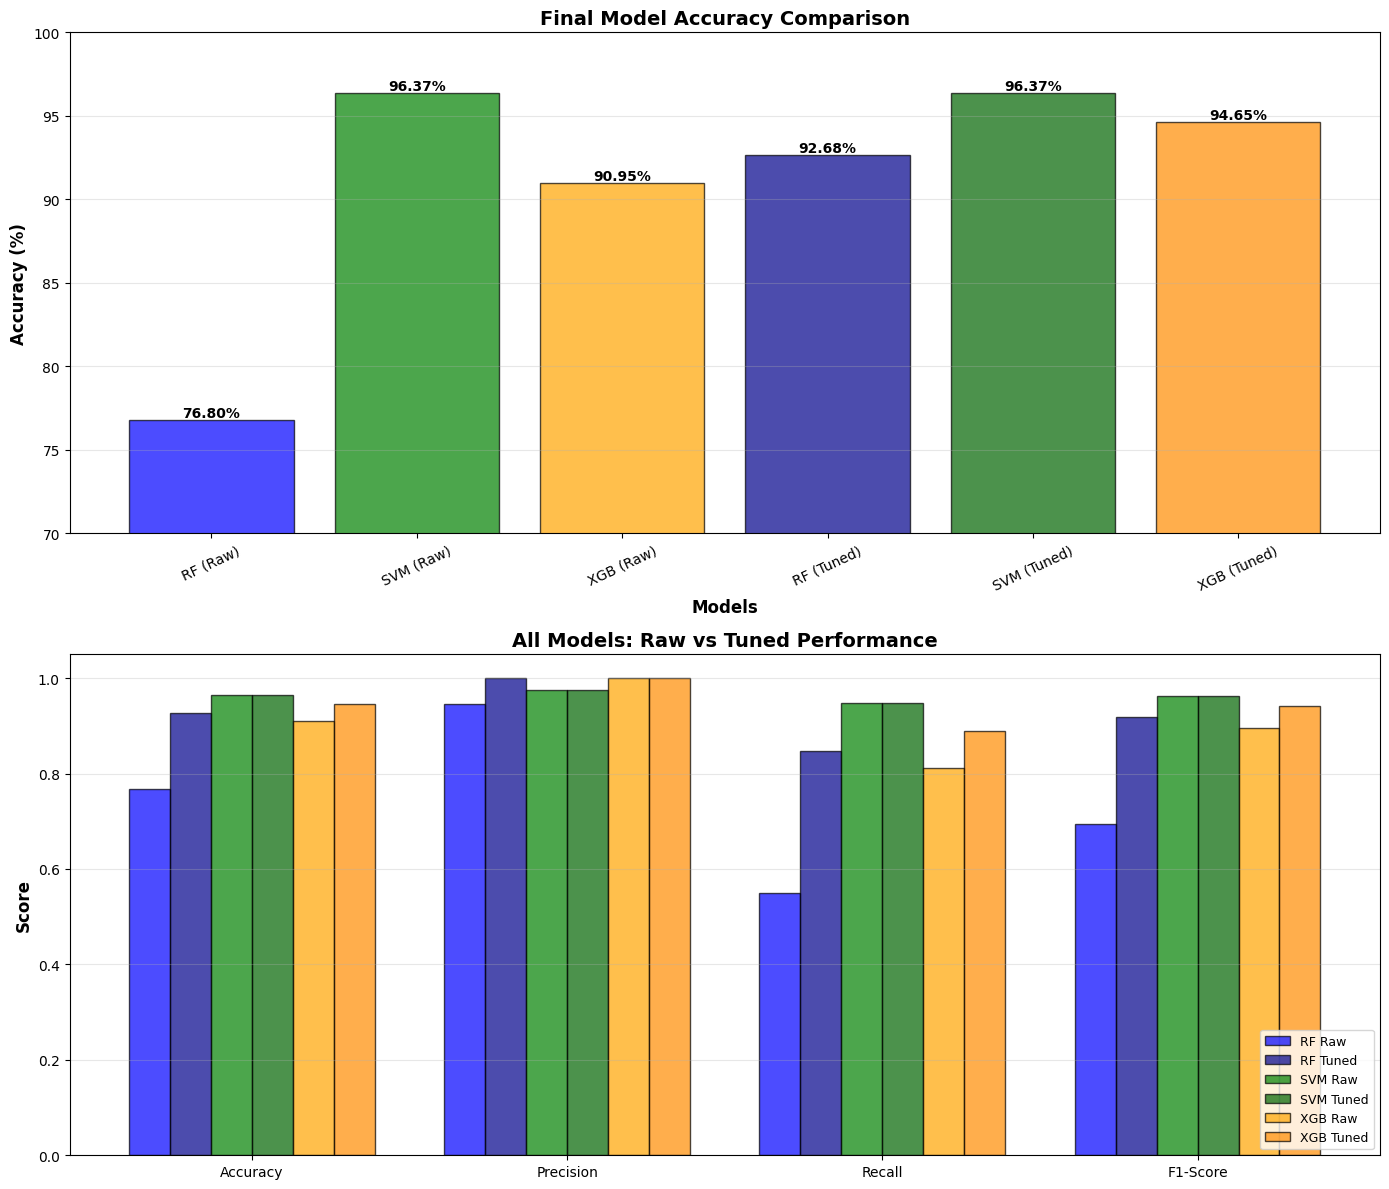

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

models = ['RF (Raw)', 'SVM (Raw)', 'XGB (Raw)', 'RF (Tuned)', 'SVM (Tuned)', 'XGB (Tuned)']
accuracies = [rf_raw_accuracy * 100, svm_raw_accuracy * 100, xgb_raw_accuracy * 100,
              rf_tuned_accuracy * 100, svm_tuned_accuracy * 100, xgb_tuned_accuracy * 100]
colors = ['blue', 'green', 'orange', 'darkblue', 'darkgreen', 'darkorange']

bars = axes[0].bar(models, accuracies, color=colors, alpha=0.7, edgecolor='black')
axes[0].set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Models', fontsize=12, fontweight='bold')
axes[0].set_title('Final Model Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylim(70, 100)
axes[0].grid(axis='y', alpha=0.3)
axes[0].tick_params(axis='x', rotation=25)

for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
rf_raw_vals = [rf_raw_accuracy, rf_raw_precision, rf_raw_recall, rf_raw_f1]
rf_tuned_vals = [rf_tuned_accuracy, rf_tuned_precision, rf_tuned_recall, rf_tuned_f1]
svm_raw_vals = [svm_raw_accuracy, svm_raw_precision, svm_raw_recall, svm_raw_f1]
svm_tuned_vals = [svm_tuned_accuracy, svm_tuned_precision, svm_tuned_recall, svm_tuned_f1]
xgb_raw_vals = [xgb_raw_accuracy, xgb_raw_precision, xgb_raw_recall, xgb_raw_f1]
xgb_tuned_vals = [xgb_tuned_accuracy, xgb_tuned_precision, xgb_tuned_recall, xgb_tuned_f1]

x = np.arange(len(metrics))
width = 0.13

bars1 = axes[1].bar(x - 2.5*width, rf_raw_vals, width, label='RF Raw', color='blue', alpha=0.7, edgecolor='black')
bars2 = axes[1].bar(x - 1.5*width, rf_tuned_vals, width, label='RF Tuned', color='darkblue', alpha=0.7, edgecolor='black')
bars3 = axes[1].bar(x - 0.5*width, svm_raw_vals, width, label='SVM Raw', color='green', alpha=0.7, edgecolor='black')
bars4 = axes[1].bar(x + 0.5*width, svm_tuned_vals, width, label='SVM Tuned', color='darkgreen', alpha=0.7, edgecolor='black')
bars5 = axes[1].bar(x + 1.5*width, xgb_raw_vals, width, label='XGB Raw', color='orange', alpha=0.7, edgecolor='black')
bars6 = axes[1].bar(x + 2.5*width, xgb_tuned_vals, width, label='XGB Tuned', color='darkorange', alpha=0.7, edgecolor='black')

axes[1].set_ylabel('Score', fontsize=12, fontweight='bold')
axes[1].set_title('All Models: Raw vs Tuned Performance', fontsize=14, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics)
axes[1].legend(fontsize=9, loc='lower right')
axes[1].set_ylim(0, 1.05)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
print("="*60)
print("TESTING PREDICTIONS WITH SVM TUNED MODEL")
print("="*60)

sample_indices = [0, 50, 100, 150, 200]
sample_data = X_test.iloc[sample_indices]
actual_labels = y_test[sample_indices]

predictions = svm_tuned.predict(sample_data)
prediction_proba = svm_tuned.predict_proba(sample_data)

label_mapping = {0: 'Edible', 1: 'Poisonous'}

print("\nSample Predictions:\n")
for i, idx in enumerate(sample_indices):
    actual = label_mapping[actual_labels[i]]
    predicted = label_mapping[predictions[i]]
    confidence = prediction_proba[i][predictions[i]] * 100

    status = "CORRECT" if actual == predicted else "WRONG"

    print(f"Sample {i+1}:")
    print(f"  Actual: {actual}")
    print(f"  Predicted: {predicted}")
    print(f"  Confidence: {confidence:.2f}%")
    print(f"  Status: {status}")
    print("-" * 40)

print("\n" + "="*60)

TESTING PREDICTIONS WITH SVM TUNED MODEL

Sample Predictions:

Sample 1:
  Actual: Edible
  Predicted: Edible
  Confidence: 98.80%
  Status: CORRECT
----------------------------------------
Sample 2:
  Actual: Poisonous
  Predicted: Poisonous
  Confidence: 100.00%
  Status: CORRECT
----------------------------------------
Sample 3:
  Actual: Edible
  Predicted: Edible
  Confidence: 46.09%
  Status: CORRECT
----------------------------------------
Sample 4:
  Actual: Poisonous
  Predicted: Poisonous
  Confidence: 100.00%
  Status: CORRECT
----------------------------------------
Sample 5:
  Actual: Edible
  Predicted: Edible
  Confidence: 99.18%
  Status: CORRECT
----------------------------------------



In [ ]:
import sklearn
import xgboost
import pandas as pd
import numpy as np
import sys
import matplotlib
import seaborn

print("="*60)
print("LIBRARY VERSIONS")
print("="*60)
print(f"Python: {sys.version}")
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")
print(f"Scikit-learn: {sklearn.__version__}")
print(f"XGBoost: {xgboost.__version__}")
print(f"Matplotlib: {matplotlib.__version__}")
print(f"Seaborn: {seaborn.__version__}")
print("="*60)

LIBRARY VERSIONS
Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
NumPy: 2.0.2
Pandas: 2.2.2
Scikit-learn: 1.6.1
XGBoost: 3.2.0
Matplotlib: 3.10.0
Seaborn: 0.13.2


In [ ]:
import joblib
import pickle

print("="*60)
print("SAVING MODELS")
print("="*60)

joblib.dump(rf_raw, 'random_forest_raw_model.pkl')
print("Random Forest Raw Model saved as 'random_forest_raw_model.pkl'")

joblib.dump(rf_tuned, 'random_forest_tuned_model.pkl')
print("Random Forest Tuned Model saved as 'random_forest_tuned_model.pkl'")

joblib.dump(svm_raw, 'svm_raw_model.pkl')
print("SVM Raw Model saved as 'svm_raw_model.pkl'")

joblib.dump(svm_tuned, 'svm_tuned_model.pkl')
print("SVM Tuned Model saved as 'svm_tuned_model.pkl'")

joblib.dump(xgb_raw, 'xgboost_raw_model.pkl')
print("XGBoost Raw Model saved as 'xgboost_raw_model.pkl'")

joblib.dump(xgb_tuned, 'xgboost_tuned_model.pkl')
print("XGBoost Tuned Model saved as 'xgboost_tuned_model.pkl'")

print("\n" + "="*60)
print("ALL MODELS SAVED SUCCESSFULLY!")
print("="*60)

SAVING MODELS
Random Forest Raw Model saved as 'random_forest_raw_model.pkl'
Random Forest Tuned Model saved as 'random_forest_tuned_model.pkl'
SVM Raw Model saved as 'svm_raw_model.pkl'
SVM Tuned Model saved as 'svm_tuned_model.pkl'
XGBoost Raw Model saved as 'xgboost_raw_model.pkl'
XGBoost Tuned Model saved as 'xgboost_tuned_model.pkl'

ALL MODELS SAVED SUCCESSFULLY!


In [ ]:
import zipfile
import os
from google.colab import files

print("="*60)
print("CREATING ZIP FILE OF ALL MODELS")
print("="*60)

zip_filename = 'mushroom_classification_models.zip'

model_files = [
    'random_forest_raw_model.pkl',
    'random_forest_tuned_model.pkl',
    'svm_raw_model.pkl',
    'svm_tuned_model.pkl',
    'xgboost_raw_model.pkl',
    'xgboost_tuned_model.pkl'
]

with zipfile.ZipFile(zip_filename, 'w') as zipf:
    for model_file in model_files:
        if os.path.exists(model_file):
            zipf.write(model_file)
            print(f"Added {model_file} to ZIP")

print("\n" + "="*60)
print(f"ZIP file created: {zip_filename}")
print("Downloading ZIP file...")
print("="*60)

files.download(zip_filename)
print("\nDownload started!")

CREATING ZIP FILE OF ALL MODELS
Added random_forest_raw_model.pkl to ZIP
Added random_forest_tuned_model.pkl to ZIP
Added svm_raw_model.pkl to ZIP
Added svm_tuned_model.pkl to ZIP
Added xgboost_raw_model.pkl to ZIP
Added xgboost_tuned_model.pkl to ZIP

ZIP file created: mushroom_classification_models.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Download started!
